# 01 — Data Audit: Hospital Readmission Risk
**Project:** Predicting 30-day hospital readmission for diabetic patients
**Data:** UCI Diabetes 130-US Hospitals (1999–2008)

**Goal of this notebook:** download the data, check its quality, define the target, and flag leakage risks before any modelling.

In [1]:
from pathlib import Path
import io, zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
RAW = Path("data/raw")
FIG = Path("figures")
RAW.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


## 1. Download the data (runs once)

In [2]:
URL = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"
csv_path = RAW / "diabetic_data.csv"

if not csv_path.exists():
    r = requests.get(URL, timeout=120)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(RAW)
    # the zip may nest files in a subfolder: move them up if so
    for f in RAW.rglob("*.csv"):
        if f.parent != RAW:
            f.rename(RAW / f.name)

print(sorted(p.name for p in RAW.glob("*.csv")))

['IDS_mapping.csv', 'diabetic_data.csv']


## 2. Load
`?` marks missing values. `keep_default_na=False` matters: pandas would otherwise turn the literal string **"None"** (used in `max_glu_serum` and `A1Cresult` to mean *test not taken*) into NaN.

In [3]:
df = pd.read_csv(csv_path, na_values=["?"], keep_default_na=False, low_memory=False)
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Missing values

In [4]:
missing = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
missing = missing[missing > 0].rename("pct_missing").to_frame()
missing

,pct_missing
weight,96.9
medical_specialty,49.1
payer_code,39.6
race,2.2
diag_3,1.4
diag_2,0.4


## 4. Target: 30-day readmission

In [5]:
print(df["readmitted"].value_counts(normalize=True).round(3))

df["readmit_30"] = (df["readmitted"] == "<30").astype(int)
print(f"\n30-day readmission rate: {df['readmit_30'].mean():.1%}")

readmitted
NO     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64

30-day readmission rate: 11.2%


## 5. Repeat patients
Patients appear in multiple encounters. If the same patient lands in both train and test sets, the model can memorise them. **Every split later must be grouped by `patient_nbr`.**

In [6]:
enc_per_patient = df.groupby("patient_nbr").size()
print(f"Encounters: {len(df):,}   Unique patients: {enc_per_patient.size:,}")
print(f"Patients with >1 encounter: {(enc_per_patient > 1).mean():.1%}")
enc_per_patient.describe()

Encounters: 101,766   Unique patients: 71,518
Patients with >1 encounter: 23.5%


count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
dtype: float64

## 6. Leakage check: discharges that make readmission impossible
Patients who died or went to hospice cannot be readmitted, so they would teach the model a false signal.
IDs from `IDS_mapping.csv`: 11, 19, 20, 21 = expired; 13, 14 = hospice.

In [7]:
EXCLUDE_DISCHARGE = [11, 13, 14, 19, 20, 21]
mask = df["discharge_disposition_id"].isin(EXCLUDE_DISCHARGE)
print(f"Encounters to exclude: {mask.sum():,} ({mask.mean():.1%})")
print(f"Their 30-day readmission rate: {df.loc[mask, 'readmit_30'].mean():.1%}")

Encounters to exclude: 2,423 (2.4%)
Their 30-day readmission rate: 1.8%


## 7. Readmission rate by key factors

In [8]:
def rate_table(col):
    return (df.groupby(col)["readmit_30"]
              .agg(encounters="size", readmit_rate="mean")
              .assign(readmit_rate=lambda t: (t.readmit_rate * 100).round(1)))

rate_table("age")

,encounters,readmit_rate
age,,
[0-10),161,1.9
[10-20),691,5.8
[20-30),1657,14.2
[30-40),3775,11.2
[40-50),9685,10.6
[50-60),17256,9.7
[60-70),22483,11.1
[70-80),26068,11.8
[80-90),17197,12.1


In [9]:
prior = pd.cut(df["number_inpatient"], [-1, 0, 1, 2, 4, np.inf],
               labels=["0", "1", "2", "3-4", "5+"])
tbl = df.groupby(prior, observed=True)["readmit_30"].agg(encounters="size", readmit_rate="mean")
tbl["readmit_rate"] = (tbl["readmit_rate"] * 100).round(1)
tbl

,encounters,readmit_rate
number_inpatient,,
0,67630,8.4
1,19521,12.9
2,7566,17.4
3-4,5033,21.4
5+,2016,36.4


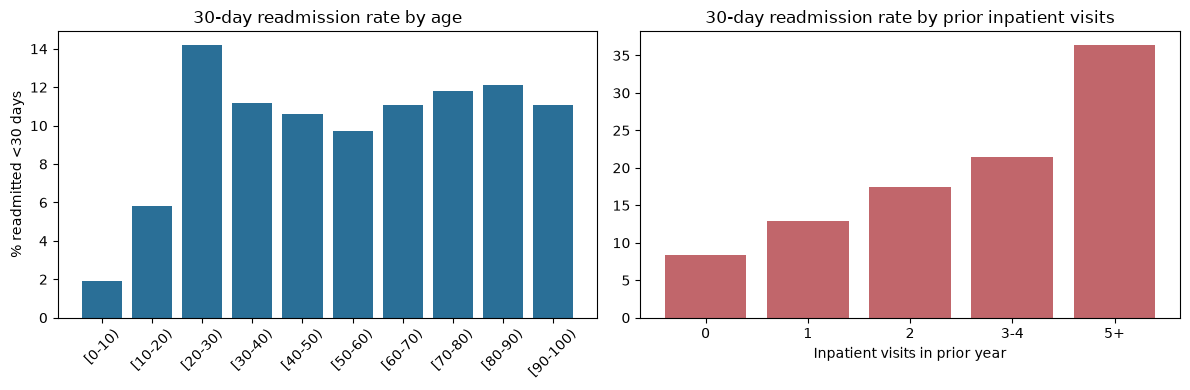

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

age = rate_table("age")
axes[0].bar(age.index, age["readmit_rate"], color="#2a6f97")
axes[0].set_title("30-day readmission rate by age")
axes[0].set_ylabel("% readmitted <30 days")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(tbl.index.astype(str), tbl["readmit_rate"], color="#c1666b")
axes[1].set_title("30-day readmission rate by prior inpatient visits")
axes[1].set_xlabel("Inpatient visits in prior year")

plt.tight_layout()
plt.savefig(FIG / "01_readmit_rates.png", dpi=150)
plt.show()

## 8. Other columns to decide on

In [11]:
for col in ["A1Cresult", "max_glu_serum", "change", "diabetesMed", "admission_type_id"]:
    print(f"--- {col} ---")
    print(rate_table(col), "\n")

--- A1Cresult ---
           encounters  readmit_rate
A1Cresult                          
>7               3812          10.0
>8               8216           9.9
None            84748          11.4
Norm             4990           9.7 

--- max_glu_serum ---
               encounters  readmit_rate
max_glu_serum                          
>200                 1485          12.5
>300                 1264          14.3
None                96420          11.1
Norm                 2597          11.4 

--- change ---
        encounters  readmit_rate
change                          
Ch           47011          11.8
No           54755          10.6 

--- diabetesMed ---
             encounters  readmit_rate
diabetesMed                          
No                23403           9.6
Yes               78363          11.6 

--- admission_type_id ---
                   encounters  readmit_rate
admission_type_id                          
1                       53990          11.5
2                  

In [12]:
print("Numeric summary")
df.select_dtypes("number").drop(columns=["encounter_id", "patient_nbr"]).describe().T.round(2)

Numeric summary


,count,mean,std,min,25%,50%,75%,max
admission_type_id,101766.0,2.02,1.45,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,3.72,5.28,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,5.75,4.06,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0


## 9. Findings
- **Readmission rate:** 11.2% of encounters are readmitted within 30 days, about 1 in 9. The classes are imbalanced, so accuracy is misleading. Use PR-AUC and recall.
- **Columns to drop (mostly missing):** `weight` (96.9% missing). Keep `medical_specialty` (49.1%) and `payer_code` (39.6%) with an "Unknown" category, since missingness itself may carry signal. `race` (2.2%) also gets "Unknown".
- **Encounters excluded for leakage:** 2,423 (2.4%) discharged as expired or to hospice. Their readmission rate is only 1.8%, so they would distort the model.
- **Strongest early signals:**
  - Prior inpatient visits: readmission rises from 8.4% (none) to 36.4% (5+ visits), a 4x increase and the strongest signal so far.
  - Age: flat at about 10–12% for adults, so it is a weak predictor on its own.
  - Glucose above 300: 14.3%, against about 11% overall.
  - A medication change during the stay: 11.8% vs 10.6% without one.
- **Skewed counts:** `number_emergency` (max 76) and `number_outpatient` (max 42) have extreme tails. Cap or log-transform them.
- **Implication for splitting:** 23.5% of patients have more than one encounter (up to 40). Group every split by `patient_nbr`.